In [50]:
import requests
import pandas as pd
import joblib
from datetime import datetime, timedelta

In [51]:
rf_models = joblib.load(
    "../models/rf_flood_models_3days.pkl"
)

model_features = joblib.load("../models/model_features.pkl")

model_d1 = rf_models["D+1"]
model_d2 = rf_models["D+2"]
model_d3 = rf_models["D+3"]

In [52]:
LOCATION = "Hue"  
# LOCATION = "Quang Nam"
#tự chọn

locations = {
    "Hue": {
        "latitude": 16.4637,
        "longitude": 107.5909
    },
    "Quang Nam": {
        "latitude": 15.5736,
        "longitude": 108.4740
    }
}

lat = locations[LOCATION]["latitude"]
lon = locations[LOCATION]["longitude"]

print(LOCATION, lat, lon)

Hue 16.4637 107.5909


In [53]:
weather_url = "https://api.open-meteo.com/v1/forecast"

weather_params = {
    "latitude": lat,
    "longitude": lon,
    "daily": [
        "temperature_2m_mean",
        "relative_humidity_2m_mean",
        "precipitation_sum",
        "pressure_msl_mean",
        "wind_speed_10m_max"
    ],
    "forecast_days": 7,
    "timezone": "Asia/Bangkok"
}

weather_response = requests.get(weather_url, params=weather_params)
weather_data = weather_response.json()

weather_data

{'latitude': 16.48506,
 'longitude': 107.571434,
 'generationtime_ms': 0.08547306060791016,
 'utc_offset_seconds': 25200,
 'timezone': 'Asia/Bangkok',
 'timezone_abbreviation': 'GMT+7',
 'elevation': 7.0,
 'daily_units': {'time': 'iso8601',
  'temperature_2m_mean': '°C',
  'relative_humidity_2m_mean': '%',
  'precipitation_sum': 'mm',
  'pressure_msl_mean': 'hPa',
  'wind_speed_10m_max': 'km/h'},
 'daily': {'time': ['2026-07-01',
   '2026-07-02',
   '2026-07-03',
   '2026-07-04',
   '2026-07-05',
   '2026-07-06',
   '2026-07-07'],
  'temperature_2m_mean': [28.9, 28.8, 28.8, 28.4, 28.8, 30.2, 29.6],
  'relative_humidity_2m_mean': [83, 82, 82, 85, 82, 72, 72],
  'precipitation_sum': [4.2, 1.0, 4.7, 8.1, 0.6, 0.5, 0.4],
  'pressure_msl_mean': [1005.3,
   1005.4,
   1004.8,
   1004.6,
   1005.6,
   1004.9,
   1003.3],
  'wind_speed_10m_max': [13.4, 13.6, 12.3, 10.0, 9.4, 8.3, 10.6]}}

In [54]:
weather_df = pd.DataFrame({
    "date": weather_data["daily"]["time"],
    "rainfall": weather_data["daily"]["precipitation_sum"],
    "temperature": weather_data["daily"]["temperature_2m_mean"],
    "humidity": weather_data["daily"]["relative_humidity_2m_mean"],
    "pressure": weather_data["daily"]["pressure_msl_mean"],
    "wind_speed": weather_data["daily"]["wind_speed_10m_max"]
})

weather_df["date"] = pd.to_datetime(weather_df["date"])
weather_df["location"] = LOCATION

weather_df

,date,rainfall,temperature,humidity,pressure,wind_speed,location
0,2026-07-01,4.2,28.9,83,1005.3,13.4,Hue
1,2026-07-02,1.0,28.8,82,1005.4,13.6,Hue
2,2026-07-03,4.7,28.8,82,1004.8,12.3,Hue
3,2026-07-04,8.1,28.4,85,1004.6,10.0,Hue
4,2026-07-05,0.6,28.8,82,1005.6,9.4,Hue
5,2026-07-06,0.5,30.2,72,1004.9,8.3,Hue
6,2026-07-07,0.4,29.6,72,1003.3,10.6,Hue


In [55]:
flood_url = "https://flood-api.open-meteo.com/v1/flood"

flood_params = {
    "latitude": lat,
    "longitude": lon,
    "longitude": lon,
    "daily": [
        "river_discharge",
        "river_discharge_mean",
        "river_discharge_max",
        "river_discharge_min"
    ],
    "forecast_days": 7,
    "timezone": "Asia/Bangkok"
}

flood_response = requests.get(flood_url, params=flood_params)
flood_data = flood_response.json()

flood_data

{'latitude': 16.475006,
 'longitude': 107.57501,
 'generationtime_ms': 1.2645721435546875,
 'utc_offset_seconds': 25200,
 'timezone': 'Asia/Bangkok',
 'timezone_abbreviation': 'GMT+7',
 'elevation': 7.0,
 'daily_units': {'time': 'iso8601',
  'river_discharge': 'm³/s',
  'river_discharge_mean': 'm³/s',
  'river_discharge_max': 'm³/s',
  'river_discharge_min': 'm³/s'},
 'daily': {'time': ['2026-07-01',
   '2026-07-02',
   '2026-07-03',
   '2026-07-04',
   '2026-07-05',
   '2026-07-06',
   '2026-07-07'],
  'river_discharge': [1.34, 1.8, 1.56, 1.05, 0.77, 1.05, 1.3],
  'river_discharge_mean': [0.96, 1.7, 1.43, 1.0, 0.87, 1.07, 1.21],
  'river_discharge_max': [2.33, 3.12, 3.88, 2.71, 2.11, 5.15, 9.38],
  'river_discharge_min': [0.61, 1.4, 1.0, 0.66, 0.53, 0.45, 0.44]}}

In [56]:
river_df = pd.DataFrame({
    "date": flood_data["daily"]["time"],
    "river_discharge": flood_data["daily"]["river_discharge"],
    "river_discharge_mean": flood_data["daily"]["river_discharge_mean"],
    "river_discharge_max": flood_data["daily"]["river_discharge_max"],
    "river_discharge_min": flood_data["daily"]["river_discharge_min"]
})

river_df["date"] = pd.to_datetime(river_df["date"])

river_df

,date,river_discharge,river_discharge_mean,river_discharge_max,river_discharge_min
0,2026-07-01,1.34,0.96,2.33,0.61
1,2026-07-02,1.80,1.70,3.12,1.40
2,2026-07-03,1.56,1.43,3.88,1.00
3,2026-07-04,1.05,1.00,2.71,0.66
4,2026-07-05,0.77,0.87,2.11,0.53
5,2026-07-06,1.05,1.07,5.15,0.45
6,2026-07-07,1.30,1.21,9.38,0.44


In [57]:
forecast = weather_df.merge(
    river_df,
    on="date",
    how="inner"
)

forecast

,date,rainfall,temperature,humidity,pressure,wind_speed,location,river_discharge,river_discharge_mean,river_discharge_max,river_discharge_min
0,2026-07-01,4.2,28.9,83,1005.3,13.4,Hue,1.34,0.96,2.33,0.61
1,2026-07-02,1.0,28.8,82,1005.4,13.6,Hue,1.80,1.70,3.12,1.40
2,2026-07-03,4.7,28.8,82,1004.8,12.3,Hue,1.56,1.43,3.88,1.00
3,2026-07-04,8.1,28.4,85,1004.6,10.0,Hue,1.05,1.00,2.71,0.66
4,2026-07-05,0.6,28.8,82,1005.6,9.4,Hue,0.77,0.87,2.11,0.53
5,2026-07-06,0.5,30.2,72,1004.9,8.3,Hue,1.05,1.07,5.15,0.45
6,2026-07-07,0.4,29.6,72,1003.3,10.6,Hue,1.30,1.21,9.38,0.44


In [58]:
forecast = forecast.sort_values("date").reset_index(drop=True)

forecast["rainfall_3days"] = (
    forecast["rainfall"]
    .rolling(window=3, min_periods=1)
    .sum()
)

forecast["rainfall_7days"] = (
    forecast["rainfall"]
    .rolling(window=7, min_periods=1)
    .sum()
)

forecast["river_discharge_change"] = (
    forecast["river_discharge"]
    .diff()
    .fillna(0)
)

forecast["month"] = forecast["date"].dt.month

def get_season(month):
    if month in [9, 10, 11, 12]:
        return "Rainy"
    else:
        return "Dry"

forecast["season"] = forecast["month"].apply(get_season)

forecast

,date,rainfall,temperature,humidity,pressure,wind_speed,location,river_discharge,river_discharge_mean,river_discharge_max,river_discharge_min,rainfall_3days,rainfall_7days,river_discharge_change,month,season
0,2026-07-01,4.2,28.9,83,1005.3,13.4,Hue,1.34,0.96,2.33,0.61,4.2,4.2,0.00,7,Dry
1,2026-07-02,1.0,28.8,82,1005.4,13.6,Hue,1.80,1.70,3.12,1.40,5.2,5.2,0.46,7,Dry
2,2026-07-03,4.7,28.8,82,1004.8,12.3,Hue,1.56,1.43,3.88,1.00,9.9,9.9,-0.24,7,Dry
3,2026-07-04,8.1,28.4,85,1004.6,10.0,Hue,1.05,1.00,2.71,0.66,13.8,18.0,-0.51,7,Dry
4,2026-07-05,0.6,28.8,82,1005.6,9.4,Hue,0.77,0.87,2.11,0.53,13.4,18.6,-0.28,7,Dry
5,2026-07-06,0.5,30.2,72,1004.9,8.3,Hue,1.05,1.07,5.15,0.45,9.2,19.1,0.28,7,Dry
6,2026-07-07,0.4,29.6,72,1003.3,10.6,Hue,1.30,1.21,9.38,0.44,1.5,19.5,0.25,7,Dry


In [59]:
#target_day = forecast.iloc[[1]].copy()
# target_day = forecast.iloc[[2]].copy()
# target_day = forecast.iloc[[3]].copy()
target_day = forecast.iloc[[0]].copy()

target_day

,date,rainfall,temperature,humidity,pressure,wind_speed,location,river_discharge,river_discharge_mean,river_discharge_max,river_discharge_min,rainfall_3days,rainfall_7days,river_discharge_change,month,season
0,2026-07-01,4.2,28.9,83,1005.3,13.4,Hue,1.34,0.96,2.33,0.61,4.2,4.2,0.0,7,Dry


In [60]:
input_features = [
    "rainfall",
    "temperature",
    "humidity",
    "pressure",
    "wind_speed",
    "river_discharge",
    "rainfall_3days",
    "rainfall_7days",
    "river_discharge_change",
    "month",
    "season",
    "location"
]

input_data = target_day[input_features].copy()

input_data = pd.get_dummies(input_data)

input_data = input_data.reindex(
    columns=model_features,
    fill_value=0
)

input_data

,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,rainfall_3days,rainfall_7days,river_discharge_change,month,season_Dry,season_Rainy,location_Hue,location_Quang Nam
0,4.2,28.9,83,1005.3,13.4,1.34,4.2,4.2,0.0,7,True,0,True,0


In [61]:
predictions = {}

for day, model in rf_models.items():
    prob = model.predict_proba(input_data)[:, 1][0]
    risk_score = round(prob * 100, 2)

    predictions[day] = {
        "flood_probability": round(prob, 4),
        "flood_risk_score": risk_score
    }

predictions

{'D+1': {'flood_probability': np.float64(0.0),
  'flood_risk_score': np.float64(0.0)},
 'D+2': {'flood_probability': np.float64(0.0),
  'flood_risk_score': np.float64(0.0)},
 'D+3': {'flood_probability': np.float64(0.0),
  'flood_risk_score': np.float64(0.0)}}

In [62]:
def get_alert_level(score):
    if score < 20:
        return "Green"
    elif score < 40:
        return "Yellow"
    elif score < 60:
        return "Orange"
    elif score < 80:
        return "Red"
    else:
        return "Severe Red"


for day in predictions:
    predictions[day]["alert_level"] = get_alert_level(
        predictions[day]["flood_risk_score"]
    )

predictions

{'D+1': {'flood_probability': np.float64(0.0),
  'flood_risk_score': np.float64(0.0),
  'alert_level': 'Green'},
 'D+2': {'flood_probability': np.float64(0.0),
  'flood_risk_score': np.float64(0.0),
  'alert_level': 'Green'},
 'D+3': {'flood_probability': np.float64(0.0),
  'flood_risk_score': np.float64(0.0),
  'alert_level': 'Green'}}

In [63]:
def get_river_trend(change):
    if change > 10:
        return "Increasing"
    elif change < -10:
        return "Decreasing"
    else:
        return "Stable"


river_trend = get_river_trend(
    target_day["river_discharge_change"].iloc[0]
)

river_trend

'Stable'

In [64]:
def get_recommendation(score):
    if score < 20:
        return "Normal condition. Continue monitoring."
    elif score < 40:
        return "Low risk. Monitor weather updates."
    elif score < 60:
        return "Moderate risk. Prepare emergency supplies."
    elif score < 80:
        return "High risk. Avoid low-lying areas and riverside roads."
    else:
        return "Severe risk. Prepare evacuation and follow official warnings."


for day in predictions:
    score = predictions[day]["flood_risk_score"]
    predictions[day]["recommendation"] = get_recommendation(score)

predictions

{'D+1': {'flood_probability': np.float64(0.0),
  'flood_risk_score': np.float64(0.0),
  'alert_level': 'Green',
  'recommendation': 'Normal condition. Continue monitoring.'},
 'D+2': {'flood_probability': np.float64(0.0),
  'flood_risk_score': np.float64(0.0),
  'alert_level': 'Green',
  'recommendation': 'Normal condition. Continue monitoring.'},
 'D+3': {'flood_probability': np.float64(0.0),
  'flood_risk_score': np.float64(0.0),
  'alert_level': 'Green',
  'recommendation': 'Normal condition. Continue monitoring.'}}

In [65]:
risk_factors = []

row = target_day.iloc[0]

if row["rainfall"] > 50:
    risk_factors.append("Heavy rainfall")

if row["rainfall_3days"] > 100:
    risk_factors.append("High accumulated rainfall in 3 days")

if row["rainfall_7days"] > 200:
    risk_factors.append("High accumulated rainfall in 7 days")

if row["river_discharge_change"] > 10:
    risk_factors.append("Increasing river discharge")

if row["season"] == "Rainy":
    risk_factors.append("Rainy season")

risk_factors

[]

In [ ]:
from datetime import timedelta

results = []

base_date = pd.to_datetime(
    target_day["date"].iloc[0]
)

for day in predictions:

    horizon = int(day.replace("D+", ""))

    forecast_date = (
        base_date +
        timedelta(days=horizon)
    )

    confidence = max(
        predictions[day]["flood_probability"],
        1 - predictions[day]["flood_probability"]
    )

    result = {
        "location": LOCATION,
        "base_date": base_date,
        "forecast_date": forecast_date,
        "forecast_horizon": day,
        "flood_probability":
        predictions[day]["flood_probability"],
        "flood_risk_score": predictions[day]["flood_risk_score"],
        "confidence_score": round(confidence * 100,2),
        "alert_level": predictions[day]["alert_level"],
        "river_trend": river_trend,
        "main_risk_factors": ", ".join(risk_factors),
        "recommendation": predictions[day]["recommendation"]
    }

    results.append(result)

results_df = pd.DataFrame(results)

results_df

,location,base_date,forecast_date,forecast_horizon,flood_probability,flood_risk_score,confidence_score,alert_level,river_trend,main_risk_factors,recommendation
0,Hue,2026-07-01,2026-07-02,D+1,0.0,0.0,100.0,Green,Stable,,Normal condition. Continue monitoring.
1,Hue,2026-07-01,2026-07-03,D+2,0.0,0.0,100.0,Green,Stable,,Normal condition. Continue monitoring.
2,Hue,2026-07-01,2026-07-04,D+3,0.0,0.0,100.0,Green,Stable,,Normal condition. Continue monitoring.


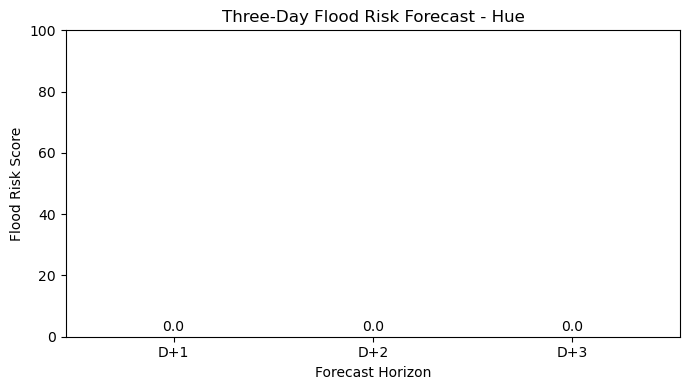

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.bar(
    results_df["forecast_horizon"],
    results_df["flood_risk_score"]
)

plt.ylim(0, 100)
plt.xlabel("Forecast Horizon")
plt.ylabel("Flood Risk Score")
plt.title(f"Three-Day Flood Risk Forecast - {LOCATION}")

for i, score in enumerate(results_df["flood_risk_score"]):
    plt.text(
        i,
        score + 2,
        str(score),
        ha="center"
    )

plt.tight_layout()
plt.show()